In [3]:
import numpy as np
import numpy.matlib
import random
import matplotlib.pyplot as plt
import time

In [4]:
plt.rcParams['figure.figsize'] = (8.0, 6.0)  

## 1. W-shape function.

\begin{equation*}
w(x) = \left\{
\begin{array}{ll}
  \sqrt{\epsilon}(x+(L+1)\sqrt{\epsilon}\,)^2 - \frac{1}{3}(x+(L+1)\sqrt{\epsilon}\,)^3 -\frac{1}{3}(3L+1)\epsilon^{3/2},
&  x \le -L\sqrt{\epsilon};\\
\epsilon x + \frac{\epsilon^{3/2}}{3} ,&-L\sqrt{\epsilon} < x \le -\sqrt{\epsilon};\\
-\sqrt{\epsilon}x^2 - \frac{x^3}{3},& -\sqrt{\epsilon} < x\le 0;\\
-\sqrt{\epsilon}x^2 + \frac{x^3}{3},&   0<x\le \sqrt{\epsilon};\\
-\epsilon x + \frac{\epsilon^{3/2}}{3} ,&\sqrt{\epsilon} < x \le L\sqrt{\epsilon};\\
\sqrt{\epsilon}(x-(L+1)\sqrt{\epsilon}\,)^2 + \frac{1}{3}(x-(L+1)\sqrt{\epsilon}\,)^3 -\frac{1}{3}(3L+1)\epsilon^{3/2},
& L\sqrt{\epsilon} < x ;
\end{array}
\right.
\end{equation*}

In [7]:
def w(x,eps = 0.01,L = 5):
    t1 = x+(L+1)*np.sqrt(eps)
    t2 = x-(L+1)*np.sqrt(eps)
    if x <=  -L * np.sqrt(eps):
        output =np.sqrt(eps) * t1**2 - 1/3 * pow(t1,3) - 1/3 * (3*L+1) * pow(eps,3/2)
    elif x <= -np.sqrt(eps):
        output = eps * x + pow(eps,3/2)/3
    elif x <= 0:
        output = - np.sqrt(eps) * x**2 - pow(x,3)/3
    elif x<= np.sqrt(eps):
        output = - np.sqrt(eps) * x**2 + pow(x,3)/3
    elif x <= L * np.sqrt(eps):
        output = -eps * x + pow(eps,3/2)/3
    else:
        output =np.sqrt(eps) * t2**2 + 1/3 * pow(t2,3) - 1/3 * (3*L+1) * pow(eps,3/2)
    return output

def w_array(x):
    y = np.zeros_like(x)
    for i in range(len(x)):
        y[i] = w(x[i])
    return y

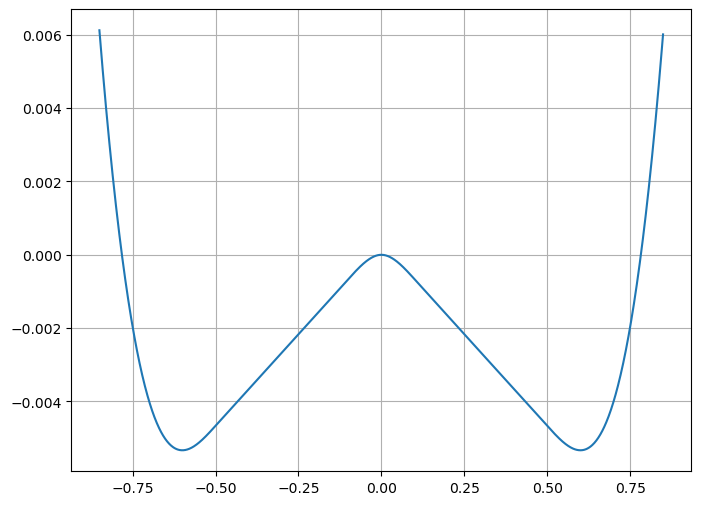

In [8]:
plt.rcParams['figure.figsize'] = (8.0, 6.0)
x = np.arange(-0.85,0.85,0.001)
y = w_array(x)
plt.grid(True)
plt.plot(x,y)
# plt.xlim(-0.85,0.85)
# plt.savefig('w.pdf')
plt.show()

## 2. Design the objective function.

Consider nonconvex-strongly concave minmax optimization problem:
$$
\min_{x\in \mathbb{R}^3}\max_{y\in\mathbb{R}^2}f(x,y) = w(x_3) - 10y_1^2+x_1y_1 - 5y_2^2+x_2y_2
$$
then,
$$
\Phi(x) = w(x_3) + \frac{x_1^2}{40} + \frac{x_2^2}{20} \ .
$$

In [11]:
def f(x,y):
    return float(w(x[2]) - y[0]**2 * 10 - 5*y[1]**2  + x[1]*y[1] + x[0]*y[0])

def Phi(x):
    return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))

We can compute $$\Phi(x^*) = \Phi\left((0,0,0.6)^T\right) $$

In [13]:
Phi_star = Phi(np.array([0,0,0.6]))

## 3. Compute Gradient, Jecobian and Hessian.

In [15]:
def dw(x,eps=0.01,L=5):
    t1 = x+(L+1)*np.sqrt(eps)
    t2 = x-(L+1)*np.sqrt(eps)
    if x <=  -L * np.sqrt(eps):
        output = 2 * np.sqrt(eps) * t1 -  pow(t1,2)
    elif x <= -np.sqrt(eps):
        output = eps
    elif x <= 0:
        output = - 2 * np.sqrt(eps) * x - pow(x,2)
    elif x<= np.sqrt(eps):
        output = - 2 * np.sqrt(eps) * x + pow(x,2)
    elif x <= L * np.sqrt(eps):
        output = -eps
    else:
        output = 2 * np.sqrt(eps) * t2 +  pow(t2,2)
    return output

In [16]:
def d2w(x,eps=0.01,L=5):
    t1 = x+(L+1)*np.sqrt(eps)
    t2 = x-(L+1)*np.sqrt(eps)
    if x <=  -L * np.sqrt(eps):
        output = 2 * np.sqrt(eps) -  2 * t1
    elif x <= -np.sqrt(eps):
        output = 0
    elif x <= 0:
        output = - 2 * np.sqrt(eps) - 2 * x
    elif x<= np.sqrt(eps):
        output = - 2 * np.sqrt(eps) + 2 * x
    elif x <= L * np.sqrt(eps):
        output = 0
    else:
        output = 2 * np.sqrt(eps) +  2 * t2
    return output

In [17]:
def df_x(x,y):
    return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.

def df_y(x,y):
    return np.asmatrix([[float(x[0])-float(y[0])*20],[float(x[1])-10 * float(y[1])]])

def dPhi(x):
    return np.asmatrix([[float(x[0])/20],[float(x[1]/10)],[dw(x[2])]])

Notice that Jacobian and Hessian of $g(x,y)$ are fixed.
$$
\nabla_{xy}^2 g(x,y)=
\begin{pmatrix}
-1 & 0\\
0 & -1\\
0 & 0
\end{pmatrix}
\ 
\text{and}
\ 
\nabla_{yy}^2g(x,y)=
\begin{pmatrix}
20 & 0\\
0 & 10\\
\end{pmatrix}
$$

In [19]:
J_xy = np.mat('-1,0;0,-1;0,0')
H_yy = np.mat('20,0;0,10')
J_xy,H_yy

(matrix([[-1,  0],
         [ 0, -1],
         [ 0,  0]]),
 matrix([[20,  0],
         [ 0, 10]]))

## 4. Implement some basic alogrithms

In [21]:
def AGD(h, z0, T, alpha, beta,eps=1e-10):
    d0 = z0
    for i in range(T):
        grad = df_y(h,d0)
        z1 = d0 + alpha * grad
        d1 = z1 + beta * (z1 - z0)
        z0,d0 = z1,d1
        if np.sqrt(float(grad.T*grad)) < eps:
#             print('T=',i)
            break
    return z1, i

## 5. PRAGDA

In [23]:
def PRAGDA(x0,eta,theta,K,B,alpha,beta,r,T):
    start_time = time.time()
    running_time = [0]
    error = []
    oracle_calls = [0]
    error.append(Phi(x0) - Phi_star)
    xi = np.mat(np.random.uniform(-r,r,[3,1]))
    x1, x0 = x0 + xi, x0 + xi
    k,s = 0,0
    y0, num = AGD(x0,np.mat('0;0'),T,alpha,beta)
    calls_num = num
    while k < K:
        w1 = x1 + (1-theta) * (x1-x0)
        y1, num = AGD(x1,y0, T, alpha,beta)
        u = df_x(w1,y1)
        x2 = w1 - eta * u
        calls_num += (1 + num)
        x0,x1,y0 = x1,x2,y1
        s += (x1-x0).T * (x1-x0)
        if (k%1==0):
            end_time = time.time()
            running_time.append(end_time-start_time)
    #         print(Phi(x1)-Phi_star)
            error.append(Phi(x1) - Phi_star)
            oracle_calls.append(calls_num)
#         print('k=',k)
#         print('k*s=',k*s)
#         print('x1 = ',x1)
        k += 1
        if k * s > B**2:
#             print('---------------------------------restarted-------------------------------')
            xi = np.mat(np.random.uniform(0,r,[3,1]))
            x1 = x1 + xi
            x0 = x1
#             print('x1 = ',x1)
            k = 0
            s = 0
            y0,num = AGD(x1,np.mat('0;0'),T,alpha,beta)
            calls_num += num
    return running_time, oracle_calls, error

In [24]:
x0 = np.mat('0.001;0.001;0.1')
eps = 1e-8
eta = 6.5
theta = 0.75
# 1/4 * eps ** (1/4)
# chi = np.log(3/(0.05 * eps))
K = 100
B = 0.5
alpha = 0.001
beta = 0.95
r = 0.000000001
T = 20
running_time1 ,oracle_calls1, error1 = PRAGDA(x0,eta,theta,K,B,alpha,beta,r,T)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.


In [25]:
x0 = np.mat('0.001;0.001;1')
eps = 1e-8
eta = 6.2
theta = 0.75
# 1/4 * eps ** (1/4)
# chi = np.log(3/(0.05 * eps))
K = 100
B = 0.5
alpha = 0.002
beta = 0.92
r = 0.000000001
T = 20
running_time11 ,oracle_calls11, error11 = PRAGDA(x0,eta,theta,K,B,alpha,beta,r,T)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.


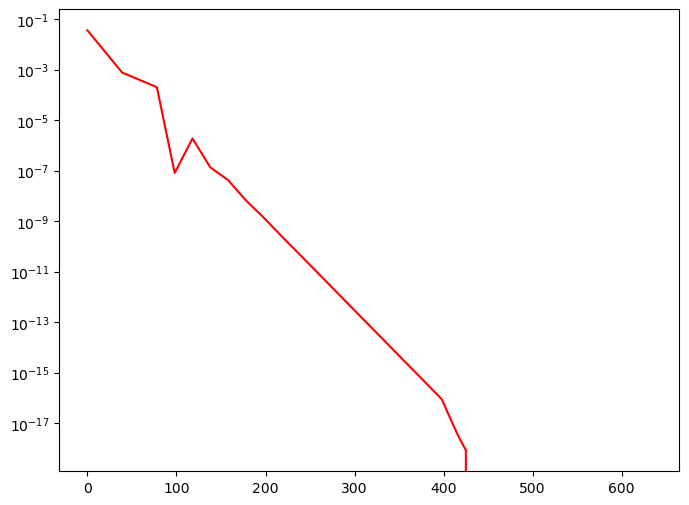

In [26]:
plt.semilogy(oracle_calls11,error11,'r-',label = 'PRAGDA')

## 6. iMCN

In [28]:
def cubic_solver(s0,K,g,H,M,eta=0.8):
    for i in range(K):
        s_norm = np.sqrt(float(s0.T * s0))
        s_grad = g + H * s0 + s_norm * s0  * M / 2
        if np.sqrt(float(s_grad.T * s_grad)) < 1e-10:
            break
        s1 = s0 - eta * s_grad
        s0 = s1
    return s0, i

In [29]:
def iMCN(x0,T,Kt,eps,M,alpha,beta, eta):
    start_time = time.time()
    running_time = [0]
    error = []
    oracle_calls = [0]
    error.append(Phi(x0) - Phi_star)
    y0 = np.mat('0;0')
    k = 0
    calls_num = 0
    while k < T:
        y1, num1 = AGD(x0,y0, Kt, alpha,beta)
        g = df_x(x0,y1)
        H = np.asmatrix([[0.05,0,0],[0,0.1,0],[0,0,d2w(float(x0[2]))]])
        s0 = np.mat('0.0;0.0;0.0')
        s1, num2 = cubic_solver(s0,Kt,g,H,M,eta)
        x1 = x0 + s1
        x0 = x1
        calls_num += (num1+num2+2)
        end_time = time.time()
        oracle_calls.append(calls_num)
        running_time.append(end_time-start_time)
#         print('k=', k)
#         print(Phi(x1)-Phi_star)
        error.append(Phi(x1) - Phi_star)
        k += 1
#         print('s1=',s1)
#         print('x0=', x0)
        if s1.T * s1 < eps / (M * 4):
            break
    return running_time, oracle_calls, error

In [30]:
x0 = np.mat('0.001;0.001;0.1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eta = 2
running_time2 ,oracle_calls2, error2 = iMCN(x0,T,Kt,eps,M,alpha,beta,eta)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\90

In [31]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eta = 0.9
running_time12 ,oracle_calls12, error12 = iMCN(x0,T,Kt,eps,M,alpha,beta,eta)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\90

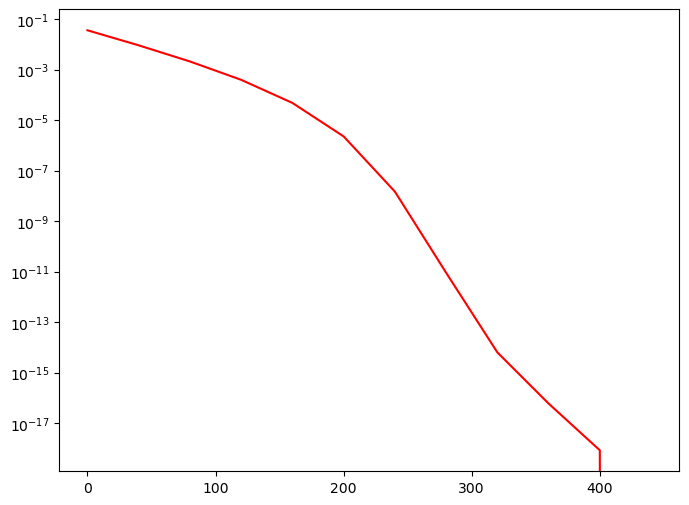

In [32]:
plt.semilogy(oracle_calls12,error12,'r-',label = 'iMCN')

## 7. GDA

In [34]:
def GDA(x0,T, eta1,eta2):
    start_time = time.time()
    running_time = [0]
    error = []
    oracle_calls = [0]
    y0 = np.mat('0;0')
    error.append(Phi(x0) - Phi_star)
    k = 0
    calls_num = 0
    while k < T:
        x1 = x0 - eta1 * df_x(x0,y0)
        y1 = y0 + eta2 * df_y(x0,y0)
        x0, y0 = x1,y1
        calls_num += 2
        if (k % 20 == 0):
            end_time = time.time()
            running_time.append(end_time-start_time)
            error.append(Phi(x1) - Phi_star)
            oracle_calls.append(calls_num)
        k += 1
    
    return running_time, oracle_calls, error

In [35]:
x0 = np.mat('0.001;0.001;0.1')
T = 601
eta1 = 5
eta2 = 0.005
running_time3, oracle_calls3, error3 = GDA(x0,T,eta1,eta2)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.


In [36]:
x0 = np.mat('0.001;0.001;1')
T = 601
eta1 = 5
eta2 = 0.005
running_time13, oracle_calls13, error13 = GDA(x0,T,eta1,eta2)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.


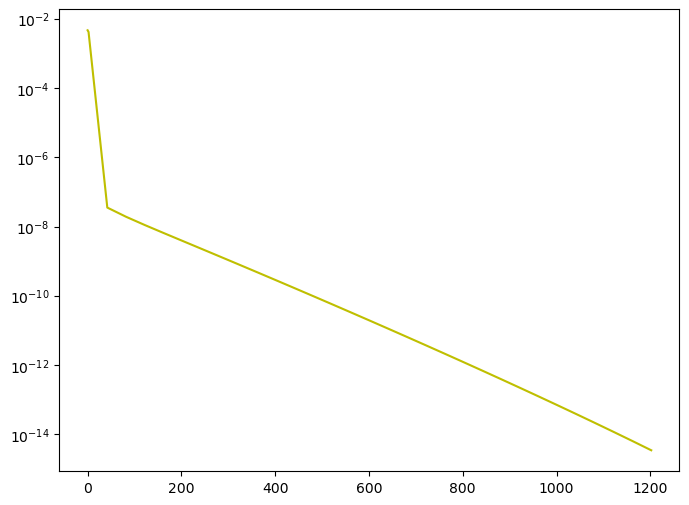

In [37]:
plt.semilogy(oracle_calls3,error3,'y-',label = 'GDA')

## 8.MCN 

In [39]:
import numpy as np
import scipy.linalg

def cubic_newton_step(Kt, g, H, M, eps1):
    
    n = g.shape[0] 
    num2 = 0        
    eps = eps1      
    max_iters = Kt

    def f(T, T_norm):
        return g.dot(T) + 0.5 * H.dot(T).dot(T) + (M / 6) * T_norm**3

    def h(r, der=False):
        A = H + M * r * np.eye(n)
        eigenvalues = np.linalg.eigvalsh(A)
        is_positive_definite = np.all(eigenvalues > 0)

        if is_positive_definite:
            try:
                ArB_cho_factor = scipy.linalg.cho_factor(A, lower=False)
                T = scipy.linalg.cho_solve(ArB_cho_factor, -g)
                T_norm = np.linalg.norm(T)
                h_r = r - T_norm
                if der:
                    BT = np.eye(n).dot(T)  
                    h_r_prime = 1 + M / T_norm * \
                                scipy.linalg.cho_solve(ArB_cho_factor, BT).T.dot(BT)
                else:
                    h_r_prime = None
            except np.linalg.LinAlgError:
                is_positive_definite = False
        else:
            U, S, Vt = np.linalg.svd(A)
            S_inv = np.diag(1 / (S + 1e-8))  
            A_inv = Vt.T @ S_inv @ U.T
            T = -A_inv @ g
            T_norm = np.linalg.norm(T)
            h_r = r - T_norm
            if der:
                BT = np.eye(n).dot(T)  
                h_r_prime = 1 + M / (T_norm + 1e-8) * ((A_inv @ BT).T @ BT)[0, 0]
            else:
                h_r_prime = None

        return h_r, T, h_r_prime

    try:
        max_r = 1  
        for i in range(max_iters):
            h_r, T, _ = h(max_r)
            num2 += 1  
            if h_r < -eps:
                max_r *= 2  
            elif -eps <= h_r <= eps:
                break       
            else:
                break      

        r = max_r
        for i in range(max_iters):
            h_r, T, h_r_prime = h(r, der=True)
            num2 += 1  
            if -eps <= h_r <= eps:
                break       
            r -= h_r / h_r_prime  

        s = T  
    except (np.linalg.LinAlgError, ValueError) as e:
        s = np.zeros_like(g) 
        print(f"error: {e}")  
    return s, num2

In [40]:
def MCN(x0,T,Kt,eps,M,alpha,beta,eps1):
    start_time = time.time()
    running_time = [0]
    error = []
    oracle_calls = [0]
    error.append(Phi(x0) - Phi_star)
    y0 = np.mat('0;0')
    k = 0
    calls_num = 0
    while k < T:
        y1, num1 = AGD(x0,y0, Kt, alpha,beta)
        g = df_x(x0,y1)
        H = np.asmatrix([[0.05,0,0],[0,0.1,0],[0,0,d2w(float(x0[2]))]])
        s1, num2 = cubic_newton_step(Kt,g,H,M,eps1)
        x1 = x0 + s1
        x0 = x1
        calls_num += (num1+num2+2)
        end_time = time.time()
        oracle_calls.append(calls_num)
        running_time.append(end_time-start_time)
        error.append(Phi(x1) - Phi_star)
        k += 1

        s1_norm_sq = np.linalg.norm(s1) ** 2  
        if s1_norm_sq < eps / (M * 4):
            break
    return running_time, oracle_calls, error

In [41]:
x0 = np.mat('0.001;0.001;0.1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
running_time4 ,oracle_calls4, error4 = MCN(x0,T,Kt,eps,M,alpha,beta,eps1)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\33

In [42]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
running_time14 ,oracle_calls14, error14 = MCN(x0,T,Kt,eps,M,alpha,beta,eps1)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\33

##  9.LMCN

In [44]:
import numpy as np

def cubic_newton_step_eig(Kt, g, Q, lam, M, eps1, denom_eps=1e-12):
    """
    Cubic-regularized Newton step using eigendecomposition of H:
        H = Q diag(lam) Q^T

    We solve for r via h(r) = r - ||T(r)|| = 0, where
        T(r) = - (H + M r I)^{-1} g
             = - Q diag(1/(lam + M r)) Q^T g

    Returns:
        s   : step (same shape as g)
        num2: number of h-evaluations (oracle calls proxy)
    """
    g = np.asarray(g, dtype=float).reshape(-1)          # (n,)
    Q = np.asarray(Q, dtype=float)                      # (n,n)
    lam = np.asarray(lam, dtype=float).reshape(-1)      # (n,)
    n = g.shape[0]
    assert Q.shape == (n, n)
    assert lam.shape == (n,)

    eps = eps1
    max_iters = Kt
    num2 = 0

    # Precompute Q^T g once
    gt = Q.T @ g   # (n,)

    def h(r, der=False):
        # denom_i = lam_i + M r
        denom = lam + M * r

        # safety: avoid division by 0 (and blow-ups)
        # If your theory guarantees denom>0, you can remove this clamp.
        denom = np.where(np.abs(denom) < denom_eps, np.sign(denom) * denom_eps + denom_eps, denom)

        # T(r) = -Q (gt / denom)
        t = - (gt / denom)           # (n,)
        T = Q @ t                    # (n,)
        T_norm = np.linalg.norm(T)

        h_val = r - T_norm

        if not der:
            return h_val, T, None

        # h'(r) = 1 - d||T||/dr
        # Using closed form:
        # h'(r) = 1 + M * sum_i gt_i^2 / denom_i^3 / ||T||
        if T_norm > 1e-15:
            h_prime = 1.0 + M * np.sum((gt**2) / (denom**3)) / T_norm
        else:
            h_prime = 1.0
        return h_val, T, h_prime

    try:
        # --- bracket phase: find r s.t. h(r) >= -eps (or close) ---
        r = 1.0
        for _ in range(max_iters):
            h_r, T, _ = h(r, der=False)
            num2 += 1
            if h_r < -eps:
                r *= 2.0
            else:
                break

        # --- Newton phase on h(r)=0 ---
        for _ in range(max_iters):
            h_r, T, h_r_prime = h(r, der=True)
            num2 += 1
            if -eps <= h_r <= eps:
                break
            r = r - h_r / h_r_prime

        s = T  # final step

    except Exception as e:
        s = np.zeros_like(g)
        print(f"error: {e}")

    return s.reshape(-1, 1), num2  # 若你习惯列向量输出

In [45]:
def LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,m):
    start_time = time.time()
    running_time = [0]
    error = []
    oracle_calls = [0]
    error.append(Phi(x0) - Phi_star)
    y0 = np.mat('0;0')
    k = 0
    calls_num = 0
    while k < T:
        y1, num1 = AGD(x0,y0, Kt, alpha,beta)
        g = df_x(x0,y1)
        if k % m == 0:
            H = np.asmatrix([[0.05, 0, 0],
                             [0, 0.1, 0],
                             [0, 0, d2w(float(x0[2]))]])
            lam, Q = np.linalg.eigh(H)
            calls_num +=1
        s1, num2 = cubic_newton_step_eig(Kt, g, Q, lam, M, eps1, denom_eps=1e-12)
        x1 = x0 + s1
        x0 = x1
        calls_num += (num1+num2+1)
        end_time = time.time()
        oracle_calls.append(calls_num)
        running_time.append(end_time-start_time)
        error.append(Phi(x1) - Phi_star)
        k += 1

        #s1_norm_sq = np.linalg.norm(s1) ** 2
        #if s1_norm_sq < eps / (M * 4):
            #break
    return running_time, oracle_calls, error

In [46]:
x0 = np.mat('0.001;0.001;0.1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.003
beta = 0.9
eps1 = 1e-8
m=3
running_time5 ,oracle_calls5, error5 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,m)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

In [47]:
x0 = np.mat('0.001;0.001;0.1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.003
beta = 0.9
eps1 = 1e-8
m=3
running_time555 ,oracle_calls555, error555 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,m)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

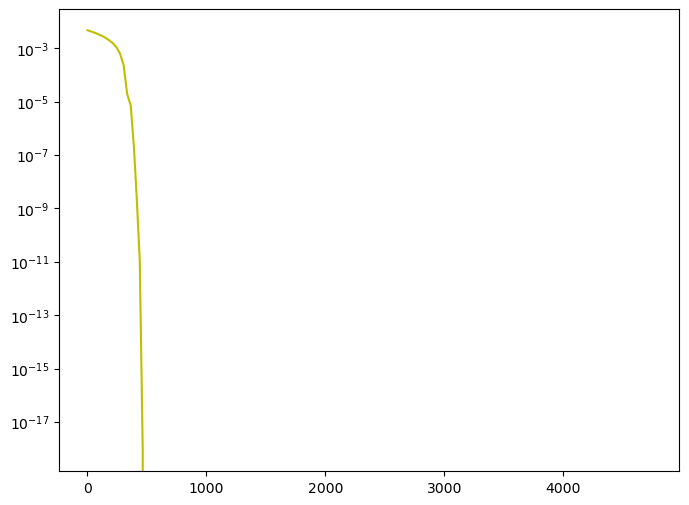

In [48]:
plt.semilogy(oracle_calls5,error5,'y-',label = 'LMCN')

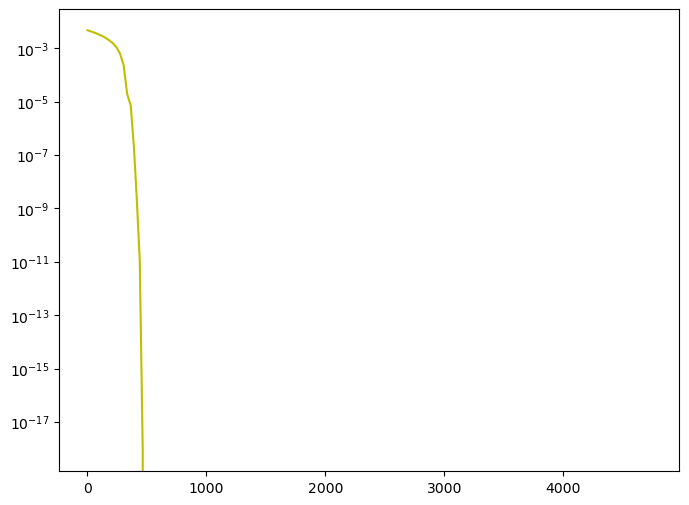

In [49]:
plt.semilogy(oracle_calls555,error555,'y-',label = 'LMCN')

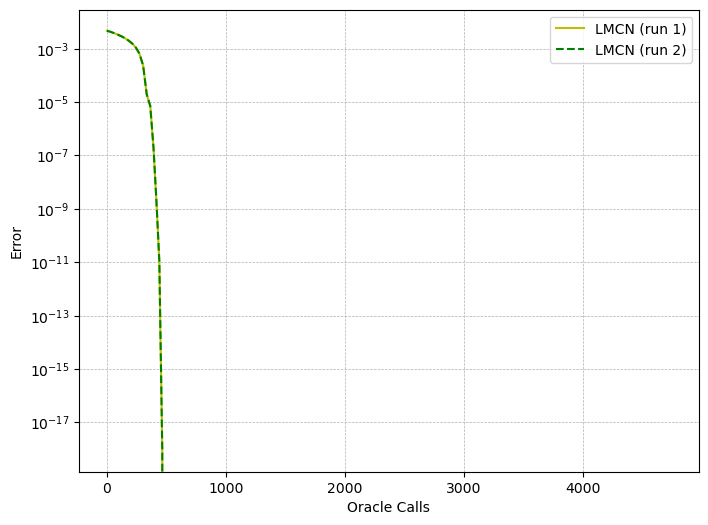

In [50]:
plt.figure()
plt.semilogy(oracle_calls5,   error5,   'y-',  label='LMCN (run 1)')
plt.semilogy(oracle_calls555, error555, 'g--', label='LMCN (run 2)')  # 改成虚线区分
plt.xlabel("Oracle Calls")
plt.ylabel("Error")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

In [51]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=3
running_time15 ,oracle_calls15, error15 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,m)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

## 10. Results comparition

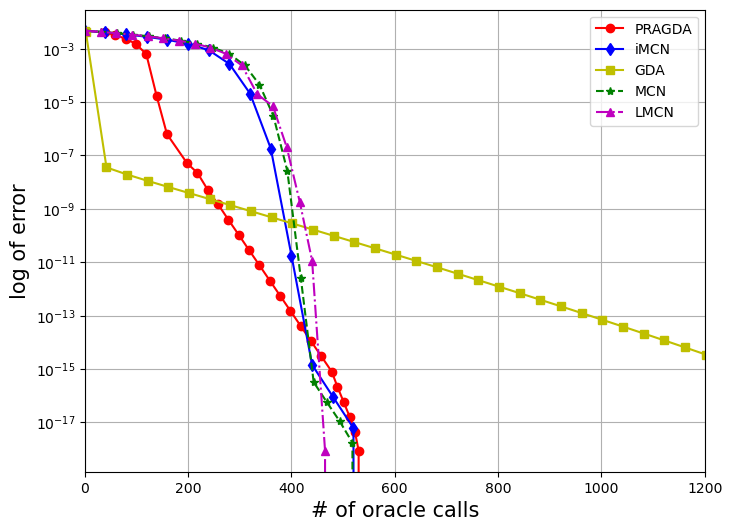

In [53]:
plt.rcParams['figure.figsize'] = (8.0, 6.0)
plt.semilogy(oracle_calls1,error1,'r-o',label = 'PRAGDA')
plt.semilogy(oracle_calls2,error2,'b-d',label = 'iMCN')
plt.semilogy(oracle_calls3,error3,'y-s',label = 'GDA')
plt.semilogy(oracle_calls4,error4,'g--*',label = 'MCN') 
plt.semilogy(oracle_calls5,error5,'m-.^',label = 'LMCN')  
plt.legend()
plt.grid(True)
plt.xlabel('# of oracle calls',fontsize = 15)
plt.xlim(0, 1200)
plt.ylabel('log of error',fontsize = 15)
plt.savefig('pragda2.pdf')
plt.show(block=True)

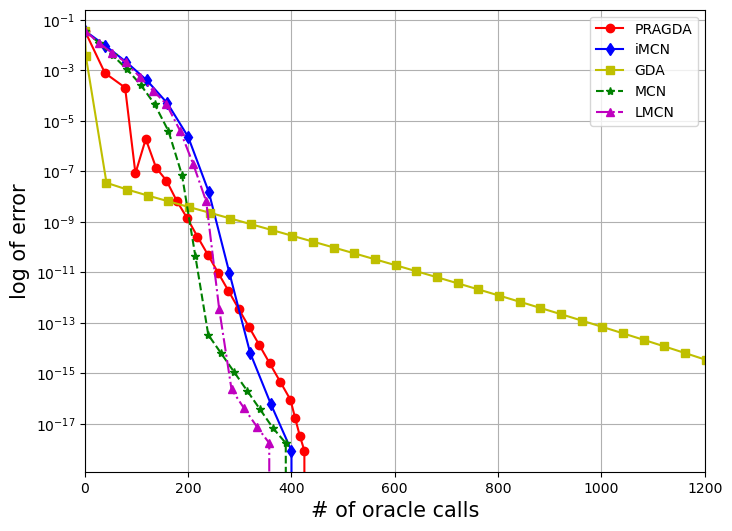

In [54]:
plt.rcParams['figure.figsize'] = (8.0, 6.0)
plt.semilogy(oracle_calls11,error11,'r-o',label = 'PRAGDA')
plt.semilogy(oracle_calls12,error12,'b-d',label = 'iMCN')   
plt.semilogy(oracle_calls13,error13,'y-s',label = 'GDA')  
plt.semilogy(oracle_calls14,error14,'g--*',label = 'MCN')  
plt.semilogy(oracle_calls15,error15,'m-.^',label = 'LMCN') 
plt.legend()
plt.grid(True)
plt.xlabel('# of oracle calls',fontsize = 15)
plt.xlim(0, 1200)
plt.ylabel('log of error',fontsize = 15)
plt.savefig('pragda3.pdf')
plt.show(block=True)

### 11.Ablation study on m

In [56]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=1
running_time_m1,  oracle_calls_m1,  error_m1  = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,1)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

In [57]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=5
running_time_m5,  oracle_calls_m5,  error_m5  = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,5)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

In [58]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=10
running_time_m10, oracle_calls_m10, error_m10 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,10)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

In [59]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=50
running_time_m50, oracle_calls_m50, error_m50 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,50)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

In [60]:
x0 = np.mat('0.001;0.001;1')
T = 1000
eps = 1e-14
Kt = 20
M=5
alpha = 0.001
beta = 0.95
eps1 = 1e-8
m=100
running_time_m100, oracle_calls_m100, error_m100 = LMCN(x0,T,Kt,eps,M,alpha,beta,eps1,100)

D:\tmp\ipykernel_46528\871168655.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(x[0]**2 / 40 + x[1]**2/20 + w(x[2]))
D:\tmp\ipykernel_46528\2650895086.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if np.sqrt(float(grad.T*grad)) < eps:
D:\tmp\ipykernel_46528\2259515932.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return np.asmatrix([[float(y[0])],[float(y[1])],[dw(float(x[2]))]])  # x and y are np.matrix type.
D:\tmp\ipykernel_46528\36

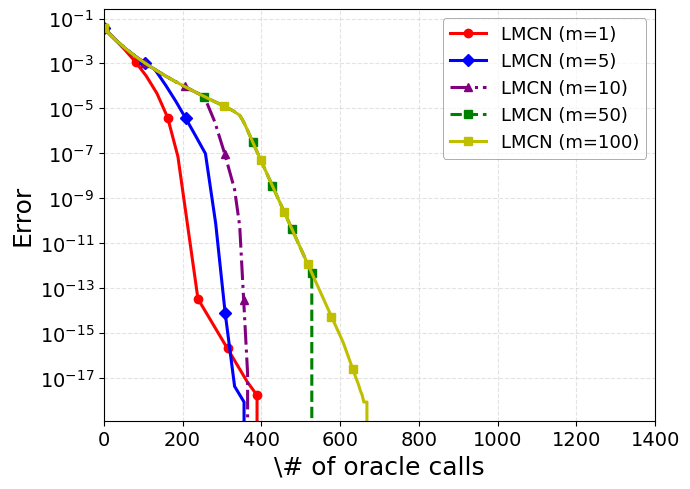

In [61]:
plt.figure(figsize=(7, 5))

plt.semilogy(oracle_calls_m1, error_m1,
             color='red', linestyle='-', marker='o',
             markevery=3, linewidth=2.2, markersize=6,
             label='LMCN (m=1)')

plt.semilogy(oracle_calls_m5, error_m5,
             color='blue', linestyle='-', marker='D',
             markevery=4, linewidth=2.2, markersize=6,
             label='LMCN (m=5)')

plt.semilogy(oracle_calls_m10, error_m10,
             color='purple', linestyle='-.', marker='^',
             markevery=4, linewidth=2.2, markersize=6,
             label='LMCN (m=10)')

plt.semilogy(oracle_calls_m50, error_m50,
             color='green', linestyle='--', marker='s',
             markevery=10, linewidth=2.2, markersize=6,
             label='LMCN (m=50)')

plt.semilogy(oracle_calls_m100, error_m100,
             color='y', linestyle='-', marker='s',
             markevery=12, linewidth=2.2, markersize=6,
             label='LMCN (m=100)')

plt.xlabel(r'\# of oracle calls', fontsize=18)
plt.ylabel('Error', fontsize=18)

plt.xlim(0, 1400)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(True, which='both', linestyle='--', alpha=0.35)

leg = plt.legend(
    fontsize=13,
    loc='upper right',
    frameon=True,
    framealpha=0.75,
    facecolor='white',
    edgecolor='gray'
)
leg.get_frame().set_linewidth(0.6)

plt.tight_layout()
plt.savefig('lmcn_m_ablation_clean.pdf', bbox_inches='tight')
plt.show()

In [62]:
import numpy as np

def first_reach_threshold(oracle_calls, error, threshold=1e-17):
    oracle_calls = np.asarray(oracle_calls, dtype=float)
    error = np.asarray(error, dtype=float)

    # 
    mask = np.isfinite(oracle_calls) & np.isfinite(error)
    oracle_calls = oracle_calls[mask]
    error = error[mask]

    idx = np.where(error <= threshold)[0]
    if len(idx) == 0:
        return None  # 
    return oracle_calls[idx[0]]

# ：
call_m1  = first_reach_threshold(oracle_calls_m1,  error_m1,  1e-17)
call_m5  = first_reach_threshold(oracle_calls_m5,  error_m5,  1e-17)
call_m10 = first_reach_threshold(oracle_calls_m10, error_m10, 1e-17)
call_m50 = first_reach_threshold(oracle_calls_m50, error_m50, 1e-17)
call_m100 = first_reach_threshold(oracle_calls_m100, error_m100, 1e-17)

print("m=1 :", call_m1)
print("m=5 :", call_m5)
print("m=10:", call_m10)
print("m=50:", call_m50)
print("m=100:", call_m100)

m=1 : 364.0
m=5 : 332.0
m=10: 369.0
m=50: 534.0
m=100: 644.0
